In [3]:
import numpy as np
from PIL import Image
import cv2
import torch
from depth_anything.dpt import DepthAnything
from depth_anything.util.transform import Resize, NormalizeImage, PrepareForNet
from torchvision.transforms import Compose


In [2]:
import os, torch
from safetensors.torch import save_file

repo = "/workspace/CS566_Project/.hf_cache/depth_anything_vitl14"
bin_path = os.path.join(repo, "pytorch_model.bin")
sft_path = os.path.join(repo, "model.safetensors")

state = torch.load(bin_path, map_location="cpu")

# Some checkpoints wrap weights in 'state_dict' or similar
for k in ("state_dict", "model", "module"):
    if isinstance(state, dict) and k in state and isinstance(state[k], dict):
        state = state[k]
        break

# Keep only tensor entries (HF loader expects a flat name->tensor dict)
tensor_state = {k: v for k, v in state.items() if torch.is_tensor(v)}
save_file(tensor_state, sft_path)
print(f"Converted {len(tensor_state)} tensors -> {sft_path}")

ModuleNotFoundError: No module named 'safetensors'

In [4]:
import os
os.environ["HF_HUB_OFFLINE"] = "1"

from depth_anything.dpt import DepthAnything

local_repo = "/workspace/CS566_Project/.hf_cache/depth_anything_vitl14"
model = DepthAnything.from_pretrained(
    local_repo,
    local_files_only=True,
    cache_dir=local_repo
).eval()  # add .cuda() if you want GPU

HFValidationError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': '/workspace/CS566_Project/.hf_cache/depth_anything_vitl14'. Use `repo_type` argument if needed.

In [6]:
image = Image.open("./Test_IMG.jpg")
#find image size
width, height = image.size
print(f"Image size: {width}x{height}")

Image size: 4766x4760


In [7]:
model = DepthAnything.from_pretrained("LiheYoung/depth_anything_vitl14")
transform = Compose([
        Resize(
            width=4760,
            height=4760,
            resize_target=False,
            keep_aspect_ratio=True,
            ensure_multiple_of=14,
            resize_method='lower_bound',
            image_interpolation_method=cv2.INTER_CUBIC,
        ),
        NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        PrepareForNet(),
    ])

image = Image.open("./Test_IMG.jpg")
image = np.array(image) / 255.0
image = transform({'image': image})['image']
print(image.shape)
image = torch.from_numpy(image).unsqueeze(0)
print(image.shape)

with torch.no_grad():
    depth = model(image) 
    print(depth.shape)
depth = depth.squeeze(0)
print(depth.shape)

xFormers not available
xFormers not available


(3, 4760, 4760)
torch.Size([1, 3, 4760, 4760])


: 

: 

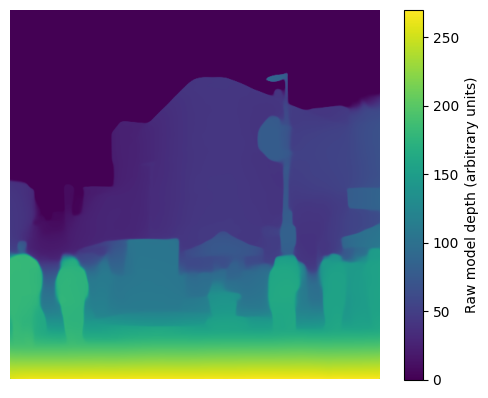

In [27]:
plt.imshow(depth)          # raw, arbitrary units for Depth Anything
plt.axis('off')
plt.colorbar(label='Raw model depth (arbitrary units)')
plt.show()

In [30]:
torch.save(depth, "depth_tensor.pt")
import os
print(os.getcwd())

/workspace/CS566_Project/Depth-Anything


pred shape: (1, 518, 518)
depth2d shape: (518, 518)


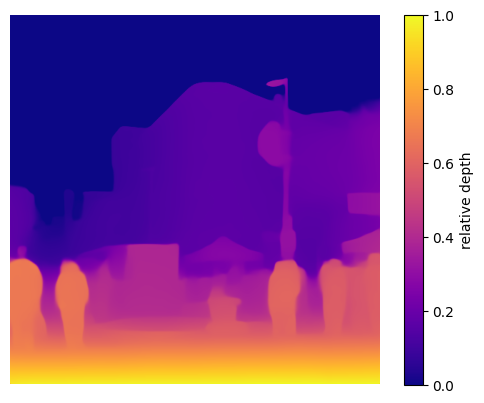

In [26]:
import torch, numpy as np, matplotlib.pyplot as plt

with torch.no_grad():
    out = model(image)  # image: [B,3,H,W]

# DepthAnything often returns a dict
pred = out['predicted_depth'] if isinstance(out, dict) else out
print("pred shape:", tuple(pred.shape))  # expect [B,1,H,W]

# Convert to 2D numpy
if pred.ndim == 4:        # [B,1,H,W]
    depth2d = pred[0, 0].detach().cpu().numpy()
elif pred.ndim == 3:      # [B,H,W] (some models)
    depth2d = pred[0].detach().cpu().numpy()
elif pred.ndim == 2:      # [H,W]
    depth2d = pred.detach().cpu().numpy()
else:
    raise RuntimeError(f"Unexpected depth shape: {pred.shape}")

print("depth2d shape:", depth2d.shape)   # must be (H, W)

# Normalize (optional) and plot
d = depth2d
d = (d - d.min()) / (d.max() - d.min() + 1e-8)

plt.imshow(d, cmap='plasma')
plt.axis('off')
plt.colorbar(label='relative depth')
plt.show()

In [28]:
depth

tensor([[[  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
         ...,
         [254.2098, 254.7628, 254.7336,  ..., 263.9360, 264.5013, 264.5054],
         [257.3887, 255.5728, 256.6427,  ..., 266.6555, 266.4049, 266.8370],
         [223.1594, 258.0603, 258.6387,  ..., 267.9090, 267.6940, 243.0849]]],
       grad_fn=<SqueezeBackward1>)